In [2]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
# 加载 .mat 文件
import matplotlib.pyplot as plt
GNSS_data = loadmat('workbench/workbench/Earthquake_predictor/reference_project/RSIT/GNSS_South_central_Alaska_20180101_20181231.mat')['GNSS_South_central_Alaska_20180101_20181231']
earthquake_data = loadmat('/home/linhang/workbench/workbench/Earthquake_predictor/reference_project/RSIT/South_central_Alaska_earthquake_event.mat')['South_central_Alaska_earthquake_event']

In [49]:
earthquake_data[0][22]

7.9

In [26]:
earthquake_happen = [i for i in range(len(earthquake_data[0])) if earthquake_data[0][i] >5]

In [27]:
earthquake_happen

[22, 23, 25, 30, 84, 85, 96, 127, 130, 198, 199, 201, 324, 333, 334, 364]

In [66]:
window = 14

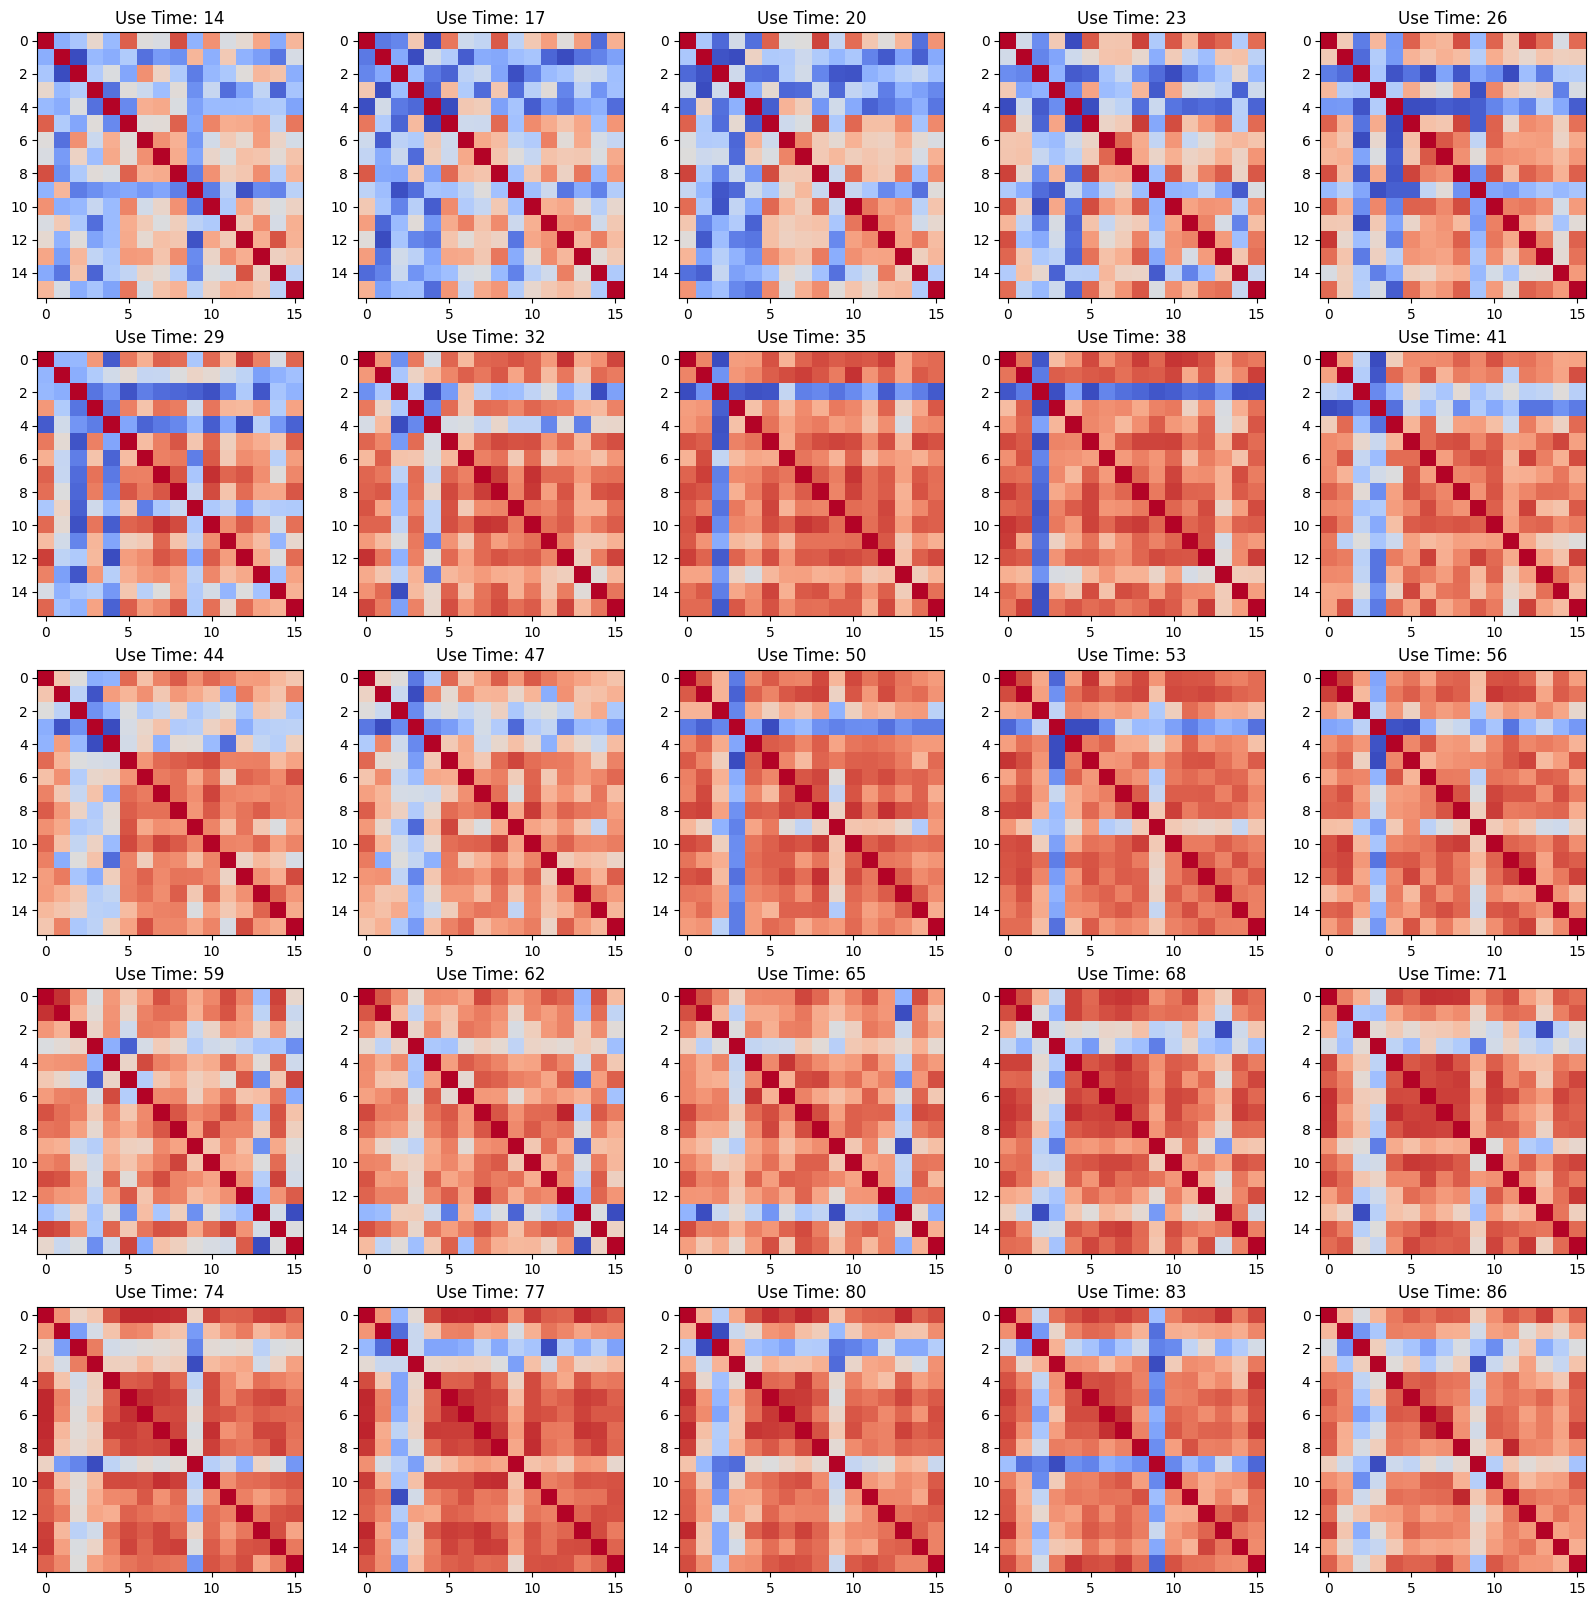

In [67]:
plt.figure(figsize=(20,20))
corr_list = []
day_list = []
count = 0
for i in range(0, 75, 3):
    count += 1
    plt.subplot(5,5,count)
    plt.title('Use Time: %d' %(i+window))
    plt.imshow(abs(np.corrcoef(GNSS_data[i:i+window,:].T)), cmap='coolwarm', interpolation='nearest')
    day_list.append(i+window)
    corr_list.append(np.corrcoef(GNSS_data[i:i+window,:].T))

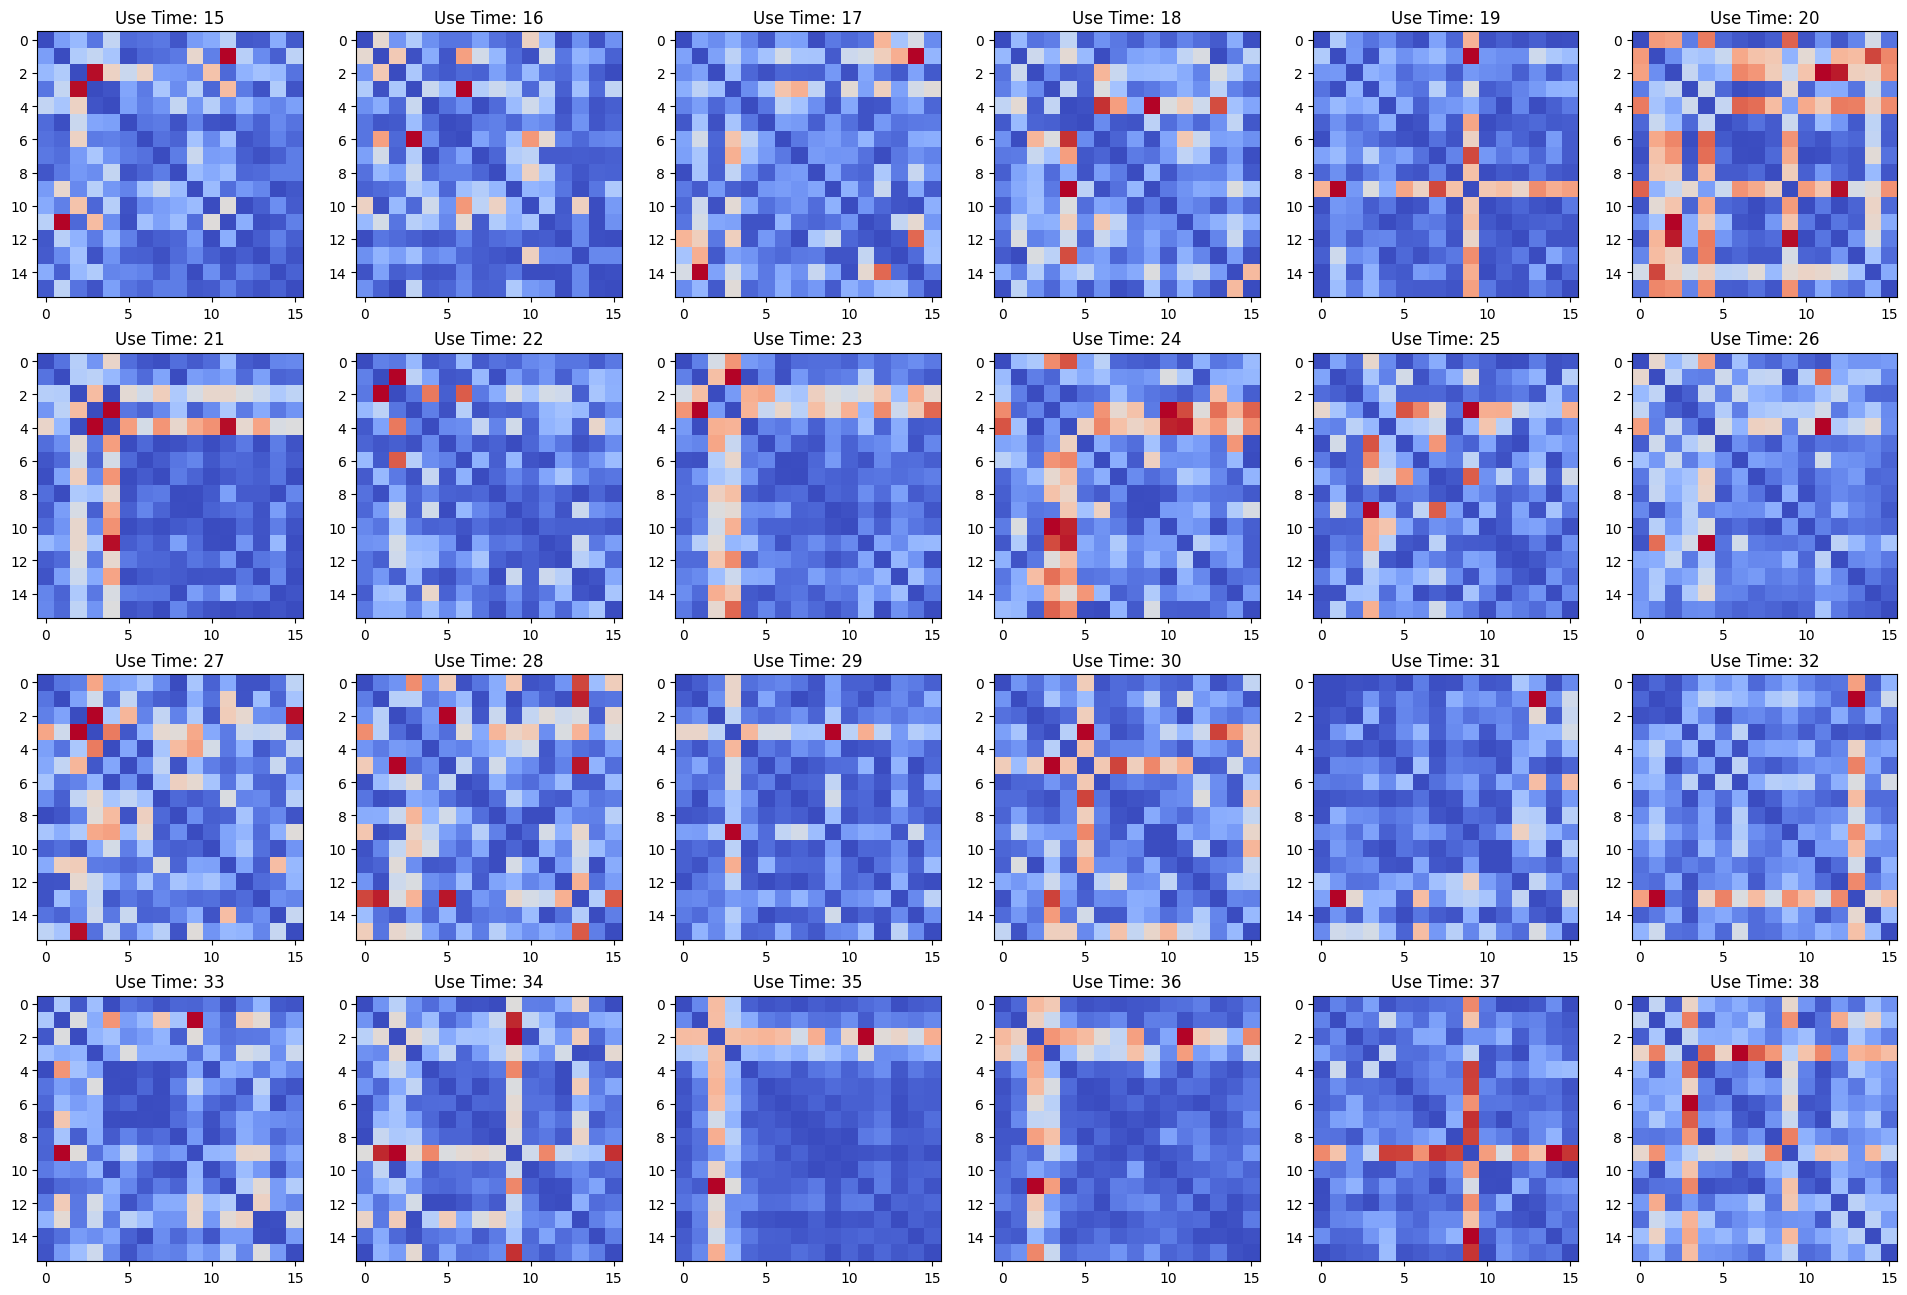

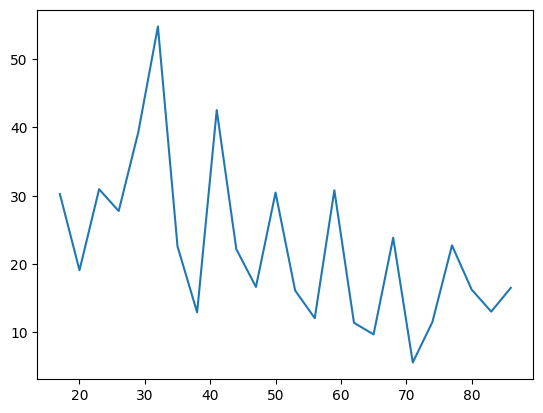

In [68]:
delta_corr_list = []
plt.figure(figsize=(24,16))
for i in range(len(corr_list)-1):
    plt.subplot(4,6,i+1)
    plt.title('Use Time: %d' %(i+window+1))
    delta_corr = abs(corr_list[i+1] - corr_list[i])
    plt.imshow(delta_corr, cmap='coolwarm', interpolation='nearest')    
    delta_corr_list.append(np.sum(delta_corr))
plt.show()
plt.plot(day_list[1:],delta_corr_list)

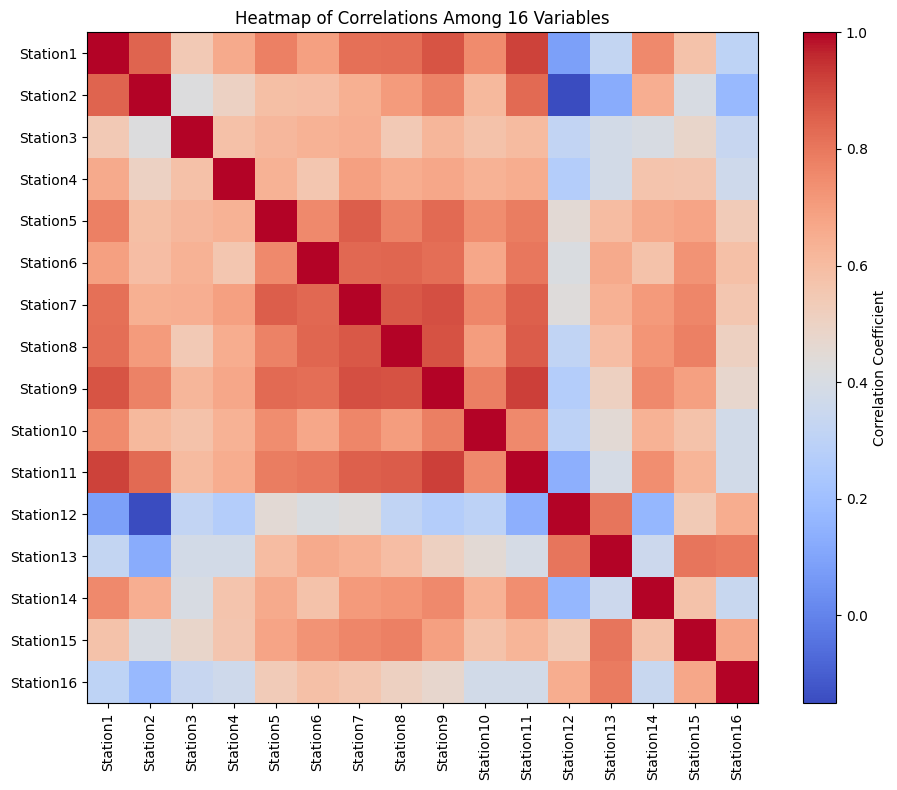

In [2]:
# Calculate the correlation matrix
correlation_matrix = np.corrcoef(GNSS_data.T)

# Plot the heatmap
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')
plt.title('Heatmap of Correlations Among 16 Variables')
plt.xticks(range(16), labels=[f'Station{i+1}' for i in range(16)], rotation=90)
plt.yticks(range(16), labels=[f'Station{i+1}' for i in range(16)])
plt.tight_layout()
plt.show()

/tmp/ipykernel_82045/3051535010.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


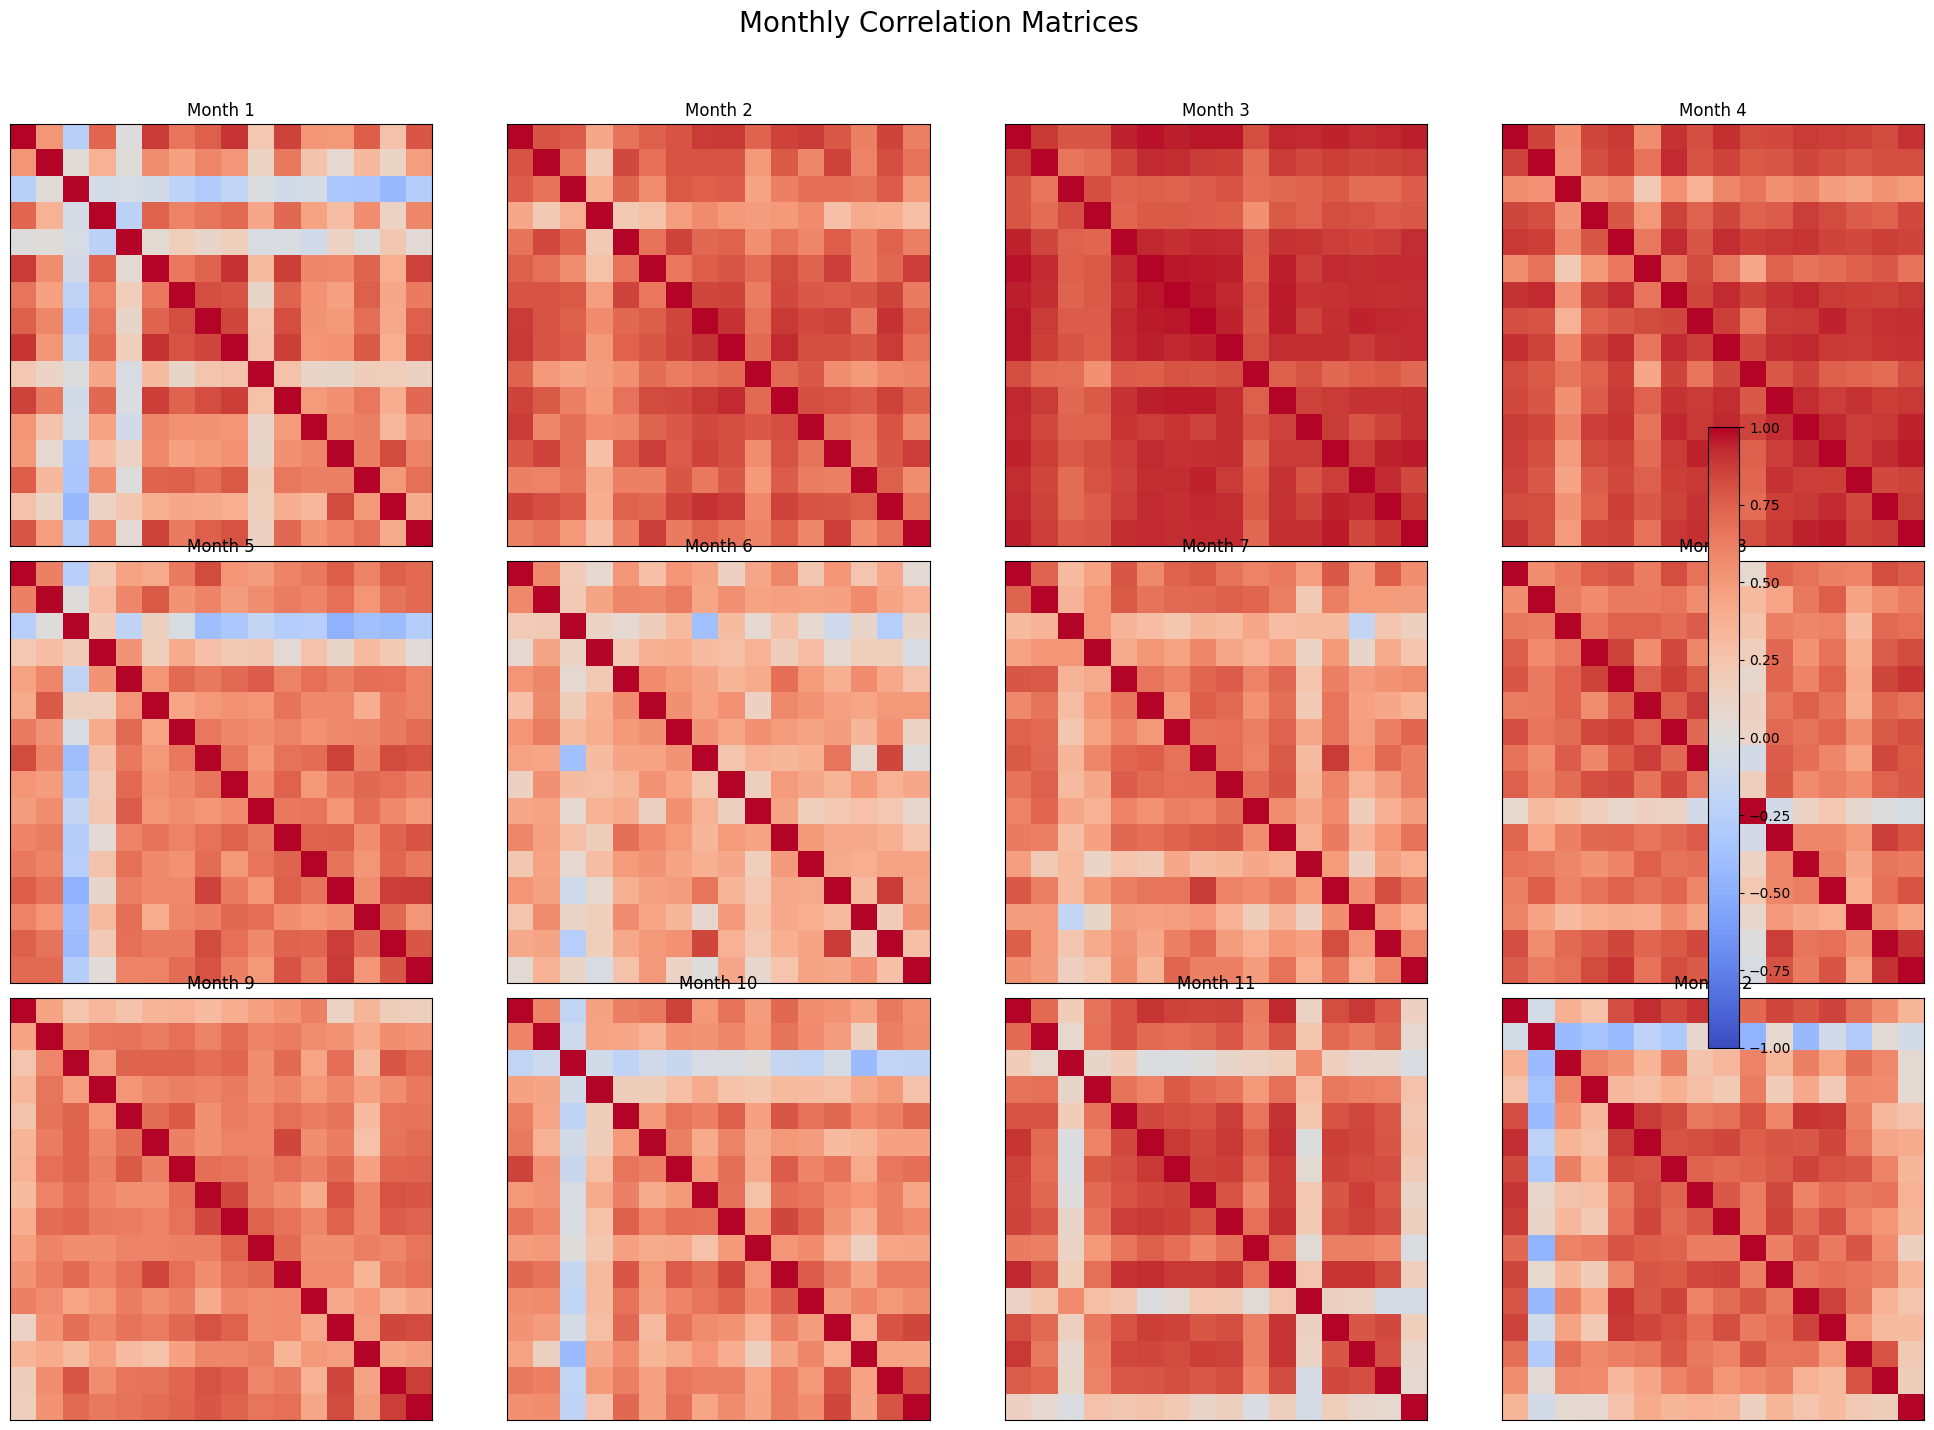

In [3]:
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

# Split the data into months
monthly_correlation_matrices = []
start_idx = 0
for days in days_in_month:
    end_idx = start_idx + days
    monthly_data = GNSS_data.T[:, start_idx:end_idx]
    monthly_corr = np.corrcoef(monthly_data)
    monthly_correlation_matrices.append(monthly_corr)
    start_idx = end_idx

# Plotting correlation changes over months as a heatmap sequence
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(monthly_correlation_matrices):
        cax = ax.imshow(monthly_correlation_matrices[i], cmap='coolwarm', interpolation='nearest', vmin=-1, vmax=1)
        ax.set_title(f'Month {i + 1}')
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.axis('off')

fig.colorbar(cax, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
plt.suptitle('Monthly Correlation Matrices', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [4]:
earthquake_magnitudes = earthquake_data[0]
days_with_large_quakes = np.where(earthquake_magnitudes > 5)[0] + 1  # Convert to 1-based index

# Map these days to months
month_mapping = []
start_day = 1
for month, days in enumerate(days_in_month, start=1):
    for day in range(start_day, start_day + days):
        month_mapping.append(month)
    start_day += days

# Get the corresponding months for the identified days
large_quake_months = [month_mapping[day - 1] for day in days_with_large_quakes]

# Count the number of large earthquakes in each month
large_quake_counts = {month: large_quake_months.count(month) for month in range(1, 13)}

import pandas as pd
quake_data = pd.DataFrame(list(large_quake_counts.items()), columns=["Month", "Count"])

<Axes: xlabel='Month'>

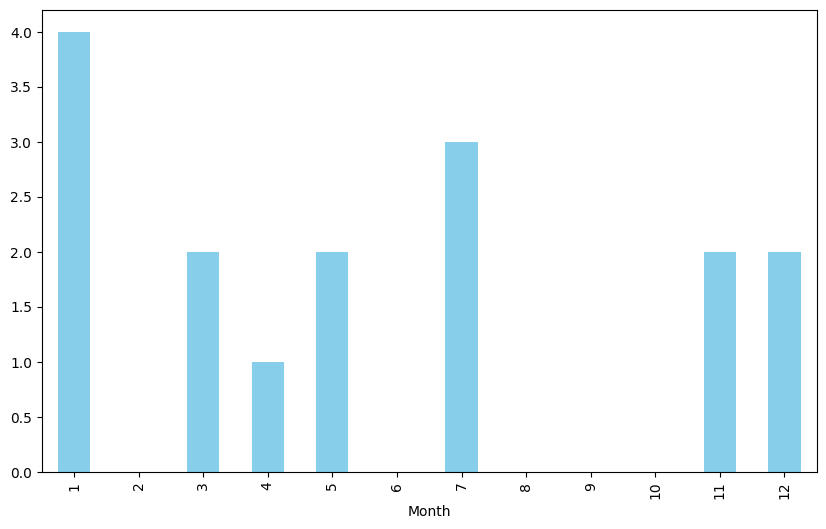

In [5]:
quake_data.plot(kind='bar', x='Month', y='Count', legend=False, color='skyblue', figsize=(10, 6))

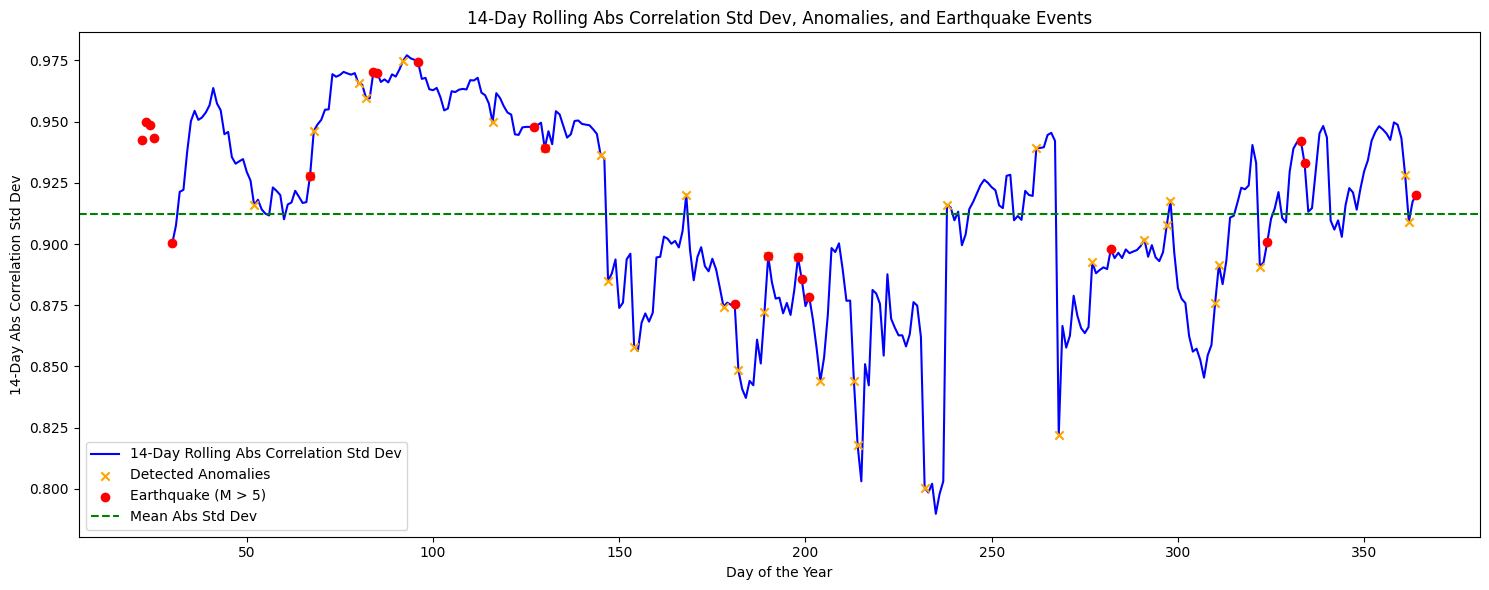

In [75]:
data = GNSS_data.T
earthquake_days = np.where(earthquake_magnitudes >= 5)[0]

rolling_abs_correlation_std = []

window_size = 30

# Loop through each day, starting from the 15th day (index 14)
for t in range(window_size, 365):
    # Extract data from the past 14 days
    past_14_days_data = data[:, t - window_size:t]
    
    # Calculate correlation matrix for the 14-day window
    window_corr = np.corrcoef(past_14_days_data)
    
    # Take absolute value of the correlation matrix
    abs_window_corr = np.abs(window_corr)
    
    # Calculate the standard deviation of the absolute correlation matrix elements
    abs_corr_std = np.max(abs_window_corr[np.triu_indices_from(abs_window_corr, k=1)])  # Exclude diagonal
    rolling_abs_correlation_std.append(abs_corr_std)

# Plot the rolling absolute standard deviation of correlation changes and earthquake events
def detect_anomalies(values, window=7, threshold_factor=2):
    anomalies = []
    for i in range(window, len(values)):
        window_data = values[i - window:i]  # Last 7 days
        mean = np.mean(window_data)
        std = np.std(window_data)
        if abs(values[i] - mean) > threshold_factor * std:
            anomalies.append(i)  # Record the index
    return anomalies

# Detect anomalies
threshold_factor = 3  # Define the threshold as 2 times the standard deviation
anomaly_indices = detect_anomalies(rolling_abs_correlation_std, window=7, threshold_factor=threshold_factor)

# Align the indices with the full 365-day range
aligned_anomaly_indices = [idx + window_size for idx in anomaly_indices]

# Plot the rolling absolute standard deviation of correlation changes and anomalies
plt.figure(figsize=(15, 6))
plt.plot(range(window_size, 365), rolling_abs_correlation_std, label='14-Day Rolling Abs Correlation Std Dev', color='blue')

# Plot anomalies
plt.scatter(
    aligned_anomaly_indices,
    [rolling_abs_correlation_std[idx - window_size] for idx in aligned_anomaly_indices],
    color='orange', label='Detected Anomalies', zorder=5, marker='x'
)

# Plot earthquake events
plt.scatter(
    earthquake_days,
    [rolling_abs_correlation_std[int(day - window_size)] for day in earthquake_days],
    color='red', label='Earthquake (M > 5)', zorder=5
)

plt.axhline(np.mean(rolling_abs_correlation_std), color='green', linestyle='--', label='Mean Abs Std Dev')
plt.xlabel('Day of the Year')
plt.ylabel('14-Day Abs Correlation Std Dev')
plt.title('14-Day Rolling Abs Correlation Std Dev, Anomalies, and Earthquake Events')
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
mark = aligned_anomaly_indices 
single = np.zeros(len(earthquake_magnitudes))
single[mark] = 1

South_central_Alaska_earthquake_event = earthquake_data

# 处理地震矩阵，只保留震级大于等于5的地震
earthquake_matrix = South_central_Alaska_earthquake_event[0, :].copy()
earthquake_matrix[earthquake_matrix < 5] = 0
Y2 = earthquake_matrix
ydata = np.random.randint(0, 2, 365)

# 初始化变量
starday = 0
earthquake = 0
acuur_single = np.zeros(len(single))
accur_earthqu = []

for i in range(starday, len(Y2)):
    if Y2[i] != 0:
        earthquake += 1
        a = max(0, i - 14)
        b = min(len(ydata)-1, i)
        if np.any(single[a:b+1] == 1):
            accur_earthqu.append(i)
            acuur_single[np.where(single[a:b+1] == 1)[0] + a] = 1

accur_earthqu = np.unique(accur_earthqu)

# 计算 acuur_mark
acuur_mark = np.where(acuur_single == 1)[0]

# 计算 TP 和 FN
TP = len(accur_earthqu)
FN = earthquake - TP

# 计算 erro_single
erro_single = single.copy()
for mmm in accur_earthqu:
    a = max(0, mmm - 14)
    b = min(len(ydata)-1, mmm)
    erro_single[a:b+1][single[a:b+1] == 1] = 0

# 计算 erro_mark
erro_mark = np.where(erro_single == 1)[0]

# 计算 FP 和 TN
FP = np.sum(erro_single[starday:])
TN = len(ydata[starday:]) - earthquake - FP

# 计算评估指标
Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
Specificity = TN / (FP + TN) if (FP + TN) > 0 else 0
Accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
error = (FP + FN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
print('TP:', TP)
print('FN:', FN)
print('FP:', FP)
print('TN:', TN)
print('Precision:', Precision)
print('TPR (Sensitivity):', TPR)
print('FPR:', FPR)
print('Specificity:', Specificity)
print('Accuracy:', Accuracy)
print('Error Rate:', error)


NameError: name 'aligned_anomaly_indices' is not defined

In [73]:
TP: 16
FN: 5
FP: 11.0
TN: 333.0
Precision: 0.5925925925925926
TPR (Sensitivity): 0.7619047619047619
FPR: 0.03197674418604651
Specificity: 0.9680232558139535
Accuracy: 0.9561643835616438
Error Rate: 0.043835616438356165


SyntaxError: illegal target for annotation (215356007.py, line 6)

In [84]:
def myLeakyRelu(x, leak, flag):
    """
    Apply LeakyReLU activation function.

    Args:
        x (ndarray): Input data.
        leak (float): Slope for negative values.
        flag (int): 1 for standard LeakyReLU, 2 for inverse LeakyReLU.

    Returns:
        ndarray: Activated output.
    """
    myleak = leak if flag == 1 else 1 / leak
    output = np.where(x >= 0, x, myleak * x)
    return output

In [85]:

def NN_transform(traindata, weights):
    """
    Transform data using a neural network structure.

    Args:
        traindata (ndarray): Input data of shape (input_dimension, trainlength).
        weights (list): List of weight matrices for each layer.

    Returns:
        ndarray: Transformed output of shape (output_dimension, trainlength).
    """
    input_dimension, trainlength = traindata.shape
    output = np.zeros((weights[-1].shape[1], trainlength))  # Initialize output matrix
    
    for i in range(trainlength):
        pre_layer_nodes_value = traindata[:, i]  # Input for the current timestep
        for weight in weights:
            curr_layer_nodes_value = np.dot(pre_layer_nodes_value, weight)
            # Apply activation function (tanh or LeakyReLU)
            curr_layer_nodes_value = np.tanh(curr_layer_nodes_value / 3.0)
            curr_layer_nodes_value = myLeakyRelu(curr_layer_nodes_value, leak=0.01, flag=1)
            pre_layer_nodes_value = curr_layer_nodes_value
        output[:, i] = curr_layer_nodes_value  # Store result for this timestep
    
    return output

In [86]:
def NN_transform_reverse(traindata_NN, weights):
    """
    Reverse transform using a neural network structure.

    Args:
        traindata_NN (ndarray): Input data of shape (input_dimension, trainlength).
        weights (list): List of weight matrices for each layer.

    Returns:
        ndarray: Reverse transformed output of shape (output_dimension, trainlength).
    """
    input_dimension, trainlength = traindata_NN.shape
    output = np.zeros((weights[0].shape[0], trainlength))  # Initialize output matrix
    
    for i in range(trainlength):
        pre_layer_nodes_value = traindata_NN[:, i]
        for weight in reversed(weights):
            pre_layer_nodes_value = myLeakyRelu(np.dot(pre_layer_nodes_value, weight.T), leak=0.01, flag=1)
        output[:, i] = pre_layer_nodes_value
    
    return output

In [87]:
def weights_align1(weight_a, weight_b, weight_c, input_dimension):
    """
    Generate weights for the neural network.

    Args:
        weight_a, weight_b, weight_c (int): Number of nodes in each layer.
        input_dimension (int): Input dimension.

    Returns:
        tuple: (all_weights, reverse_all_weights), both are lists of weight matrices.
    """
    post_nodes_num = [weight_a, weight_b, weight_c]
    layer_nodes_num = [input_dimension] + post_nodes_num
    
    all_weights = []
    reverse_all_weights = []
    
    for l in range(1, len(layer_nodes_num)):
        weight_matrix = np.random.randn(layer_nodes_num[l - 1], layer_nodes_num[l])
        all_weights.append(weight_matrix)
        reverse_all_weights.append(np.linalg.pinv(weight_matrix))
    
    return all_weights, reverse_all_weights

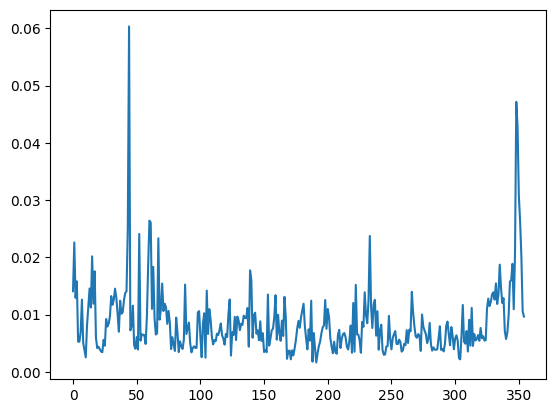

In [88]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

# 设置随机数种子
import random

# 初始化参数
samples = 11
embeddings_num = 5
weight_a = 190
weight_b = 10
weight_c = 5
stationnum = 16
sample_use = 365

altitude_matrix_databeihaidao1 = GNSS_data.T[:,:sample_use]

# 计算时间点
timepoint = sample_use - samples + 1

# 初始化变量
normal_sd_y = np.zeros((timepoint, 1))
normal_sd_original = np.zeros((stationnum, timepoint))
critical_sd_y = 0
ii = 0
good_ii = 0
reps = 0
nreps = 0


# 主循环，执行10000次迭代
while ii < 1:
    ii += 1
    input_dimensions = stationnum

    # 获取权重矩阵
    all_weights, reverse_all_weights = weights_align1(weight_a, weight_b, weight_c, altitude_matrix_databeihaidao1.shape[0])

    # 样本的关键区域
    critical_zone = np.arange(sample_use - samples, sample_use)

    normal_start = 0

    # 内部循环，遍历所有可能的正常区域
    while normal_start + samples - 1 < sample_use:
        normal_start += 1
        normal_zone = np.arange(normal_start - 1, normal_start + samples - 1)
        myzone = [normal_zone]
        # 计算正常区域的标准差
        normal_sd_original[:, normal_start - 1] = np.std(altitude_matrix_databeihaidao1[:, myzone[0]], axis=1, ddof=0)
    
        for mys in range(1):
            UU = altitude_matrix_databeihaidao1[:, myzone[mys]]

            input_dimensions, time_points = UU.shape # 16, 11

            flat_y = np.zeros((time_points + embeddings_num - 1, 1))
            xx = UU
            noisestrength = 0  # 可以添加噪声
            xx_noise = xx + noisestrength * np.random.rand(*xx.shape)
            D = xx_noise.shape[0]  # 系统中的变量数量 16
            trainlength = time_points

            traindata = xx_noise[:, :trainlength]

            traindata_x_NN = NN_transform(traindata, all_weights)
            test_NN = traindata_x_NN #(5, 11)
            
            F_dimensions = traindata_x_NN.shape[0]

            # 求解权重矩阵A
            AA_rows = (trainlength - 1) * (embeddings_num - 1) + 1
            AA_cols = embeddings_num * F_dimensions

            AA = np.zeros((AA_rows, AA_cols)) #41, 25
            b = np.zeros((AA_rows, 1))

            for k in range(embeddings_num - 1):
                for t in range(1, trainlength):
                    row_idx = k * (trainlength - 1) + t - 1
                    AA[row_idx, k * F_dimensions: (k + 1) * F_dimensions] = traindata_x_NN[:, t]
                    AA[row_idx, (k + 1) * F_dimensions: (k + 2) * F_dimensions] = -traindata_x_NN[:, t - 1]

            AA[(trainlength - 1) * (embeddings_num - 1), 0:F_dimensions] = traindata_x_NN[:, 1]
            b[(trainlength - 1) * (embeddings_num - 1), 0] = traindata_x_NN[0, 0]

            # 求解线性方程 AA * flat_A = b

            flat_A, residuals, rank, s_vals = np.linalg.lstsq(AA, b, rcond=None)

            flat_A = flat_A.flatten()

            weight_A = np.zeros((embeddings_num, F_dimensions))
            for i in range(embeddings_num):
                weight_A[i, :] = flat_A[i * F_dimensions: (i + 1) * F_dimensions]

            # 计算Y
            Y = np.dot(weight_A, traindata_x_NN)  # Y的大小为 (embeddings_num, trainlength)

            # 计算权重矩阵B
            B = np.dot(traindata_x_NN, np.linalg.pinv(Y))
            X_real = xx_noise[:, :trainlength]
            II = np.dot(weight_A, B)

            for t in range(trainlength):
                min_val = min(t + 1, embeddings_num)
                for j in range(min_val):
                    m = t - j
                    l = j
                    flat_y[t] += Y[l, m]
                flat_y[t] /= min_val

            for t in range(trainlength, trainlength + embeddings_num - 1):
                max_j = embeddings_num - (t - trainlength)
                for j in range(max_j):
                    m = trainlength - j - 1
                    l = t - trainlength + j
                    flat_y[t] += Y[l, m]
                flat_y[t] /= max_j

            # 计算标准差
            if 'sd1' not in locals():
                sd1 = np.zeros((1, flat_y.shape[0]))
                test_flat_y = np.zeros((1, flat_y.shape[0]))
            sd1[mys, :] = np.std(flat_y, axis=0, ddof=0)
            test_flat_y[mys, :] = flat_y.flatten()

        normal_sd_y[normal_start - 1, 0] += np.std(test_flat_y[0, :], ddof=0)
        reps += 1
    # 打印进度
    if ii % 100 == 0:
        print(ii)

# 计算平均标准差
normal_sd_y = normal_sd_y / ii

# 保存结果
combined_sd_y_South_central_Alaska = normal_sd_y.flatten()
plt.figure()
plt.plot(combined_sd_y_South_central_Alaska)
plt.show()

In [89]:
import numpy as np

def NN_F2(weight_a, weight_b, weight_c, weight_d, weight_e, traindata):
    """
    Implements the NN_F2 function to simulate a simple feedforward neural network.

    Parameters:
    - weight_a, weight_b, weight_c, weight_d, weight_e: Weights specifying the number of nodes in each layer.
    - traindata: Input data matrix of shape (input_dimension, trainlength).

    Returns:
    - output: Output of the neural network of shape (layer_nodes_num[-1], trainlength).
    """
    layer_nodes_num = [weight_a, weight_b, weight_c, weight_d, weight_e]
    input_dimension, trainlength = traindata.shape
    pre_layer_nodes_num = input_dimension

    # Initialize weights for all layers
    all_weights = {}
    for l in range(len(layer_nodes_num)):
        curr_layer_nodes_num = layer_nodes_num[l]
        for it in range(curr_layer_nodes_num):
            curr_node_input_weight = np.random.randn(pre_layer_nodes_num)
            all_weights[(l, it)] = curr_node_input_weight
        pre_layer_nodes_num = curr_layer_nodes_num

    # Forward pass through the network
    output = np.zeros((layer_nodes_num[-1], trainlength))
    for i in range(trainlength):
        pre_layer_nodes_num = input_dimension
        pre_layer_nodes_value = traindata[:, i]  # Input for the current sample

        for l in range(len(layer_nodes_num)):
            curr_layer_nodes_num = layer_nodes_num[l]
            curr_layer_nodes_value = []
            for it in range(curr_layer_nodes_num):
                curr_node_input_weight = all_weights[(l, it)]
                xx = np.sum(pre_layer_nodes_value * curr_node_input_weight)
                curr_layer_nodes_value.append(np.tanh(xx / 2.5))
            pre_layer_nodes_value = np.array(curr_layer_nodes_value).reshape(-1)
            pre_layer_nodes_num = curr_layer_nodes_num

        output[:, i] = pre_layer_nodes_value

    return output

In [96]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import numpy as np
from multiprocessing import Pool, cpu_count

# 假设 GNSS_data 和 sample_use 已经定义
altitude_matrix_data = GNSS_data.T[:, :sample_use]

window_len = 4
newdata = np.zeros((altitude_matrix_data.shape[0],
                    altitude_matrix_data.shape[1] - window_len + 1))

for i in range(newdata.shape[1]):
    newdata[:, i] = np.mean(altitude_matrix_data[:, i:i + window_len], axis=1)

# 初始化参数
predict_len = 4
trainlength = 9
noisestrength = 0
X = newdata

weight_a = 400
weight_b = 300
weight_c = 200
weight_d = 100
weight_e = 100

# 定义目标站点
aim_station = list(range(1, 17))

# 设置随机种子以保证可重复性
np.random.seed(42)


# 定义处理单个站点的函数
def process_station(args):
    tt, jd = args
    pcc_y = []
    Loss_y = []
    rmse_y = []
    ii = 0

    while X.shape[1] - ii >= predict_len + trainlength:
        ii += 1
        xx = X[:, ii:]
        traindata = xx[:, :trainlength]
        k = 30
        real_y = xx[jd - 1, :]
        all_real_y = X[jd - 1, :]

        traindata_y = real_y[:trainlength]

        # 生成 NN_train 数据
        traindata_x_NN = np.zeros((weight_e, trainlength))

        for i in range(trainlength):
            traindata_x_NN[:, i] = NN_F2(weight_a, weight_b, weight_c, weight_d, weight_e,
                                         traindata[:, i].reshape(-1, 1)).flatten()

        # 初始化权重矩阵
        w_flag = np.zeros(traindata_x_NN.shape[0])
        B_w = np.zeros((traindata_x_NN.shape[0], predict_len))

        # 计算系数矩阵 B
        for _ in range(1):
            available_indices = np.setdiff1d(range(traindata_x_NN.shape[0]), [jd - 1])
            if len(available_indices) < k - 1:
                random_idx = available_indices
            else:
                random_idx = np.random.choice(available_indices, k - 1, replace=False)
            random_idx = np.sort(np.append(jd - 1, random_idx))
            traindata_x = traindata_x_NN[random_idx, :trainlength]

            for i, idx in enumerate(random_idx):
                b = traindata_x[i, :(trainlength - predict_len + 1)]
                A = np.array([traindata_y[j:j + predict_len] for j in range(trainlength - predict_len + 1)])
                w = np.linalg.lstsq(A, b, rcond=None)[0]
                B_w[idx, :] = (B_w[idx, :] + w + w * (1 - w_flag[idx])) / 2
                w_flag[idx] = 1

        # 预测逻辑
        super_bb = []
        super_AA = []

        for i in range(traindata_x_NN.shape[0]):
            bb = []
            AA = np.zeros((predict_len - 1, predict_len - 1))

            for j in range(trainlength - predict_len + 1, trainlength):
                col_known_y_num = trainlength - j
                bb_val = traindata_x_NN[i, j]

                for r in range(col_known_y_num):
                    bb_val -= B_w[i, r] * traindata_y[trainlength - col_known_y_num + r]

                bb.append(bb_val)
                AA[j - (trainlength - predict_len + 1), :(predict_len - col_known_y_num)] = B_w[i, col_known_y_num:predict_len]

            super_bb.extend(bb)
            super_AA.extend(AA)

        super_bb = np.array(super_bb)
        super_AA = np.array(super_AA)

        # 预测结果
        pred_y = np.linalg.lstsq(super_AA, super_bb, rcond=None)[0]
        myreal = real_y[trainlength:trainlength + predict_len - 1]

        pcc = pearsonr(pred_y, myreal)[0]
        pcc_y.append(pcc)
        Loss = np.sqrt(mean_squared_error(pred_y, myreal)) / np.std(myreal)
        rmse = np.sqrt(mean_squared_error(pred_y, myreal))
        Loss_y.append(Loss)
        rmse_y.append(rmse)

    return pcc_y, Loss_y, rmse_y

# 并行处理
if __name__ == '__main__':
    from functools import partial

    # 将 X 传递给子进程
    global X

    # 准备参数列表
    args_list = [(tt, jd) for tt, jd in enumerate(aim_station)]

    # 使用所有可用的 CPU 核心
    num_cores = cpu_count()

    # 创建进程池并并行计算
    with Pool(processes=num_cores) as pool:
        results = pool.map(process_station, args_list)

    # 收集结果
    pcc_station = []
    loss_station = []
    rmse_station = []

    for res in results:
        pcc_y, Loss_y, rmse_y = res
        pcc_station.append(pcc_y)
        loss_station.append(Loss_y)
        rmse_station.append(rmse_y)

In [98]:
newdata.shape

(16, 362)

In [97]:
rmse_station_all_use = np.array(rmse_station)
rmse_station_all_use.shape

(16, 350)

In [99]:
rmse_station_all_use = np.array(rmse_station)
zeros_to_prepend = np.zeros((16, sample_use - rmse_station_all_use.shape[1]))
rmse_station_all_predi_4 = np.hstack((zeros_to_prepend, rmse_station_all_use))

In [102]:
rmse_station_all_predi_4[0,:17]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.00442787, 0.00108009])

In [92]:
rmse_station_all_predi_4.shape

(16, 365)

In [23]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.stats import ttest_1samp



combined_sd_y_sc1 = combined_sd_y_South_central_Alaska

# 准备 ydata
ydata = np.hstack((np.zeros(sample_use - combined_sd_y_sc1.size), combined_sd_y_sc1.flatten()))

# 准备 rmse_stationall

rmse_stationall = rmse_station_all_predi_4

# 初始化变量
loss_p = np.zeros(rmse_stationall.shape)
windows = 12

# 主循环
for j in range(rmse_stationall.shape[0]):
    now_rmse_station = rmse_stationall[j, :]
    for i in range(windows, len(now_rmse_station)):

        long_pic = now_rmse_station[i - windows:i]
        now_num = now_rmse_station[i]
        # 执行 t 检验
        t_stat, p_value = ttest_1samp(long_pic, now_num)      
        loss_p[j, i] = p_value

In [24]:
YYY = np.zeros(len(ydata))
for i in range(len(ydata)):
    YY_pic = ydata[10:14]  # MATLAB 索引 11:14 对应 Python 的 10:14
    YY_num = ydata[i]
    t_stat, p_value = ttest_1samp(YY_pic, YY_num)
    if p_value < 0.01:
        YYY[i] = 1
    else:
        YYY[i] = 0

# 收集 YYY > 0 的索引
mark1 = np.where(YYY > 0)[0]

In [25]:
# 假设已经导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 将地震数据复制到新变量
South_central_Alaska_earthquake_event = earthquake_data

# 处理地震矩阵，只保留震级大于等于5的地震
earthquake_matrix = South_central_Alaska_earthquake_event[0, :].copy()
earthquake_matrix[earthquake_matrix < 5] = 0
Y2 = earthquake_matrix

# 创建日期向量
t_start = datetime(2018, 1, 1)
t_long = t_start
t1 = np.array([t_long + timedelta(days=i) for i in range(len(ydata))])  # ydata 的日期

t_es = np.array([t_long + timedelta(days=i) for i in range(len(Y2))])    # 地震事件的日期

# 计算 mmm
number = rmse_stationall.shape[0]
mmm = np.sum(loss_p[:number, :], axis=0) / number
mmm[mmm != 0] = 1 / mmm[mmm != 0]

# 找出 mmm > 20 的索引，得到 mark3
mark3 = np.where(mmm > 20)[0]

# 计算 mark
mark = []
for m in mark1:
    a = max(0, m - 14)
    b = min(len(ydata)-1, m)
    c = min(len(ydata)-1, m + 14)
    for mk in mark3:
        if a <= mk <= b:
            mark.append(m)
            break
        elif b < mk <= c:
            mark.append(mk)
            break
mark = np.unique(mark)

# 创建 single 数组
single = np.zeros(len(ydata))
single[mark] = 1

# 初始化变量
starday = 0
earthquake = 0
acuur_single = np.zeros(len(single))
accur_earthqu = []

for i in range(starday, len(Y2)):
    if Y2[i] != 0:
        earthquake += 1
        a = max(0, i - 14)
        b = min(len(ydata)-1, i)
        if np.any(single[a:b+1] == 1):
            accur_earthqu.append(i)
            acuur_single[np.where(single[a:b+1] == 1)[0] + a] = 1
accur_earthqu = np.unique(accur_earthqu)

# 计算 acuur_mark
acuur_mark = np.where(acuur_single == 1)[0]

# 计算 TP 和 FN
TP = len(accur_earthqu)
FN = earthquake - TP

# 计算 erro_single
erro_single = single.copy()
for mmm in accur_earthqu:
    a = max(0, mmm - 14)
    b = min(len(ydata)-1, mmm)
    erro_single[a:b+1][single[a:b+1] == 1] = 0

# 计算 erro_mark
erro_mark = np.where(erro_single == 1)[0]

# 计算 FP 和 TN
FP = np.sum(erro_single[starday:])
TN = len(ydata[starday:]) - earthquake - FP

# 计算评估指标
Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
Specificity = TN / (FP + TN) if (FP + TN) > 0 else 0
Accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
error = (FP + FN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0

# 调整 acuur_single 和 erro_single 以便绘图
acuur_single[acuur_single != 0] = 4
erro_single[erro_single != 0] = 4



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


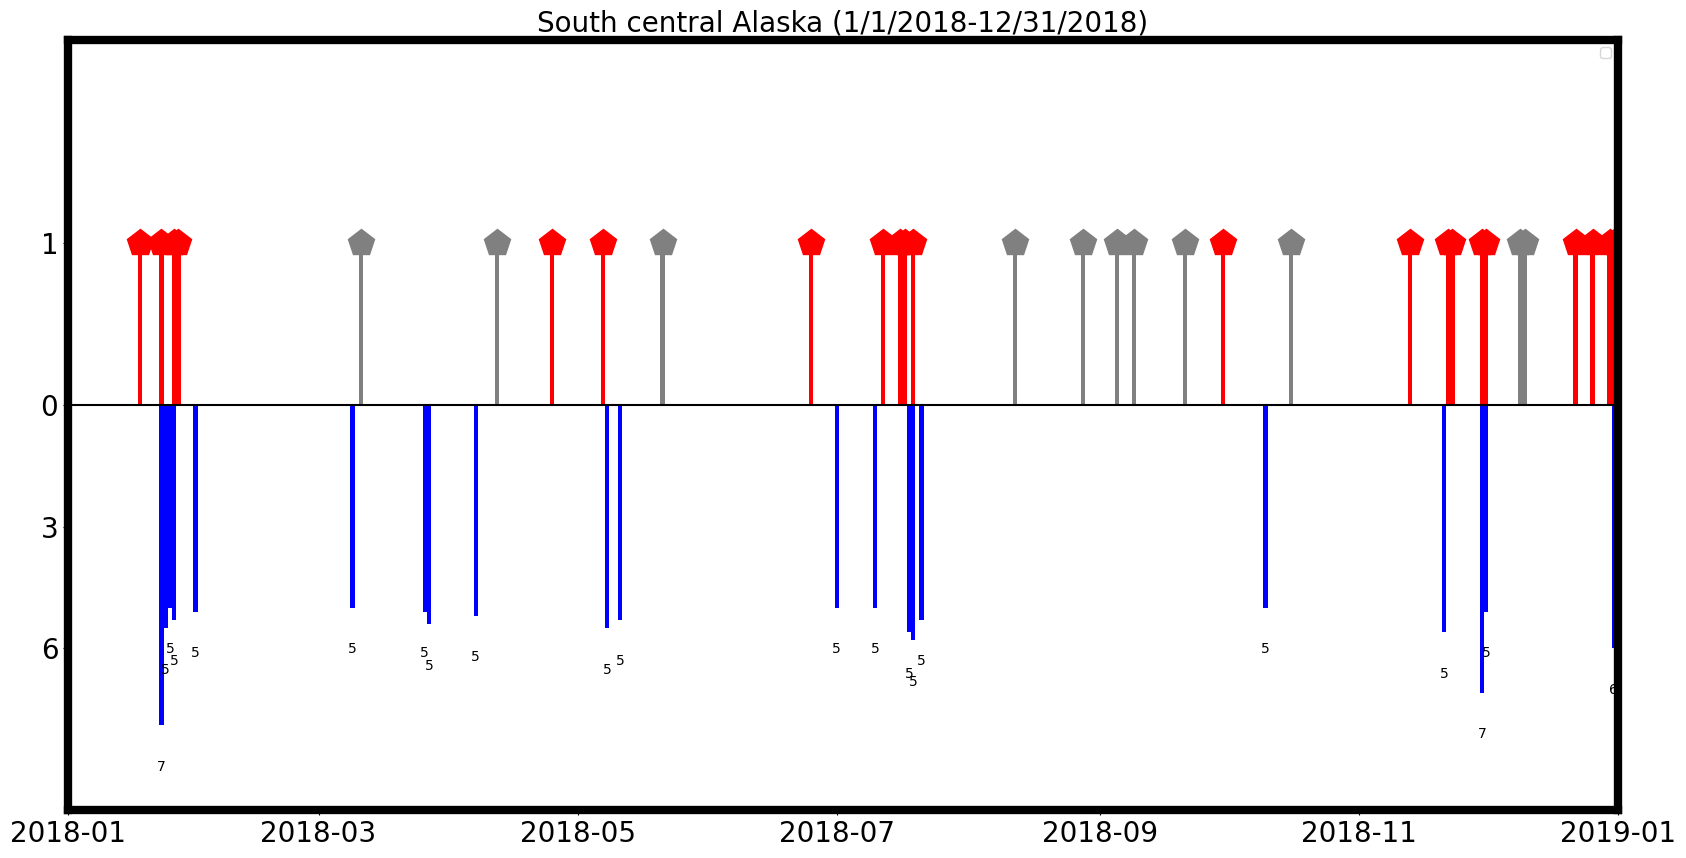

TP: 16
FN: 5
FP: 11.0
TN: 333.0
Precision: 0.5925925925925926
TPR (Sensitivity): 0.7619047619047619
FPR: 0.03197674418604651
Specificity: 0.9680232558139535
Accuracy: 0.9561643835616438
Error Rate: 0.043835616438356165


In [26]:
# 绘制原始图形，并添加 mark1 和 mark3
plt.figure(figsize=(20, 10))
demo = np.zeros(len(ydata))  # 确保 demo 的长度与 ydata 一致
plt.plot(t1, demo, color='k')

# 绘制 acuur_single
plt.bar(t1[starday:], acuur_single[starday:], color='r', width=1)

# 设置图形属性
plt.tick_params(axis='both', which='major', labelsize=20)
plt.yticks([-6, -3, 0, 4], ['6', '3', '0', '1'])
plt.gca().spines['top'].set_linewidth(6)
plt.gca().spines['right'].set_linewidth(6)
plt.gca().spines['bottom'].set_linewidth(6)
plt.gca().spines['left'].set_linewidth(6)

# 标题
plt.title('South central Alaska (1/1/2018-12/31/2018)', fontsize=20)

# 绘制 erro_single
plt.bar(t1[starday:], erro_single[starday:], color=[0.5, 0.5, 0.5], width=1)

# 绘制 erro_mark 点
for idx in erro_mark:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor=[0.5, 0.5, 0.5], markeredgecolor=[0.5, 0.5, 0.5], linewidth=2)

# 准备 Y4 以便绘制地震
Y4 = -Y2

# 添加地震的文本标签
for i in range(starday, len(Y4)):
    if Y4[i] != 0:
        plt.text(t_es[i], Y4[i]-1.2, str(int(-Y4[i])), verticalalignment='bottom', horizontalalignment='center', fontsize=10)

# 绘制地震
plt.bar(t_es[starday:], Y4[starday:], color='b', width=1)

# 绘制 acuur_mark 点
for idx in acuur_mark:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor='r', markeredgecolor='r', linewidth=2)


# 设置坐标轴范围
plt.xlim([datetime(2018, 1, 1), datetime(2019, 1, 1)])
plt.ylim([-10, 9])

# 添加图例
plt.legend()

# 显示图形
plt.show()


# 准备 AAAA
AAAA = [TP, FN, FP, TN, Precision, TPR, FPR, Specificity, Accuracy, error]
warning_effect = AAAA

# 输出结果
print('TP:', TP)
print('FN:', FN)
print('FP:', FP)
print('TN:', TN)
print('Precision:', Precision)
print('TPR (Sensitivity):', TPR)
print('FPR:', FPR)
print('Specificity:', Specificity)
print('Accuracy:', Accuracy)
print('Error Rate:', error)

In [3]:
# 绘制原始图形，并添加 mark1 和 mark3
plt.figure(figsize=(20, 10))
t_start = datetime(2018, 1, 1)
t_long = t_start
t1 = np.array([t_long + timedelta(days=i) for i in range(len(ydata))])
demo = np.zeros(len(ydata))  # 确保 demo 的长度与 ydata 一致
plt.plot(t1, demo, color='k')

# 绘制 acuur_single
plt.bar(t1[starday:], acuur_single[starday:], color='r', width=1)

# 设置图形属性
plt.tick_params(axis='both', which='major', labelsize=20)
plt.yticks([-6, -3, 0, 4], ['6', '3', '0', '1'])
plt.gca().spines['top'].set_linewidth(6)
plt.gca().spines['right'].set_linewidth(6)
plt.gca().spines['bottom'].set_linewidth(6)
plt.gca().spines['left'].set_linewidth(6)

# 标题
plt.title('South central Alaska (1/1/2018-12/31/2018)', fontsize=20)

# 绘制 erro_single
plt.bar(t1[starday:], erro_single[starday:], color=[0.5, 0.5, 0.5], width=1)

# 绘制 erro_mark 点
for idx in erro_mark:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor=[0.5, 0.5, 0.5], markeredgecolor=[0.5, 0.5, 0.5], linewidth=2)

# 准备 Y4 以便绘制地震
Y4 = -Y2
t_es = np.array([t_long + timedelta(days=i) for i in range(len(Y2))])    # 地震事件的日期
# 添加地震的文本标签
for i in range(starday, len(Y4)):
    if Y4[i] != 0:
        plt.text(t_es[i], Y4[i]-1.2, str(int(-Y4[i])), verticalalignment='bottom', horizontalalignment='center', fontsize=10)

# 绘制地震
plt.bar(t_es[starday:], Y4[starday:], color='b', width=1)

# 绘制 acuur_mark 点
for idx in acuur_mark:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor='r', markeredgecolor='r', linewidth=2)


# 设置坐标轴范围
plt.xlim([datetime(2018, 1, 1), datetime(2019, 1, 1)])
plt.ylim([-10, 9])

# 添加图例
plt.legend()

# 显示图形
plt.show()

plt.figure(figsize=(20, 10))
# 设置图形属性
plt.title('Earthquakes and Mark3', fontsize=20)
plt.xlim([datetime(2018, 1, 1), datetime(2019, 1, 1)])
plt.ylim([-10, 9])

mark3_single = np.zeros(len(ydata))
mark3_single[mark3] = 4
plt.plot(t1, demo, color='k')
plt.bar(t1, mark3_single, color='r', width=1)
for idx in mark3:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor='r', markeredgecolor='r', linewidth=2)

for i in range(starday, len(Y4)):
    if Y4[i] != 0:
        plt.text(t_es[i], Y4[i]-1.2, str(int(-Y4[i])), verticalalignment='bottom', horizontalalignment='center', fontsize=10)
plt.bar(t_es[starday:], Y4[starday:], color='b', width=1)
# 显示图形
plt.show()

plt.figure(figsize=(20, 10))
# 设置图形属性
plt.title('Earthquakes and Mark1', fontsize=20)
plt.xlim([datetime(2018, 1, 1), datetime(2019, 1, 1)])
plt.ylim([-10, 9])
mark1_single = np.zeros(len(ydata))
mark1_single[mark1] = 4
plt.plot(t1, demo, color='k')
plt.bar(t1, mark1_single, color='r', width=1)
for idx in mark1:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor='r', markeredgecolor='r', linewidth=2)
plt.bar(t_es[starday:], Y4[starday:], color='b', width=1)
for i in range(starday, len(Y4)):
    if Y4[i] != 0:
        plt.text(t_es[i], Y4[i]-1.2, str(int(-Y4[i])), verticalalignment='bottom', horizontalalignment='center', fontsize=10)
# 显示图形
plt.show()

# 准备 AAAA
AAAA = [TP, FN, FP, TN, Precision, TPR, FPR, Specificity, Accuracy, error]
warning_effect = AAAA

# 输出结果
print('TP:', TP)
print('FN:', FN)
print('FP:', FP)
print('TN:', TN)
print('Precision:', Precision)
print('TPR (Sensitivity):', TPR)
print('FPR:', FPR)
print('Specificity:', Specificity)
print('Accuracy:', Accuracy)
print('Error Rate:', error)

NameError: name 'datetime' is not defined

<Figure size 2000x1000 with 0 Axes>

In [104]:
import pickle

In [105]:
uc = pickle.load(open('/home/linhang/workbench/workbench/Earthquake_predictor/reference_project/RSIT/mark1.pkl', 'rb'))

In [106]:
uc

array([ 17,  22,  23,  26,  39,  54,  69,  71,  77, 101, 126, 175, 181,
       196, 199, 227, 241, 247, 248, 268, 325, 326, 333, 340, 342, 343,
       355, 359, 364])

In [107]:
fc = pickle.load(open('/home/linhang/workbench/workbench/Earthquake_predictor/reference_project/RSIT/mark3.pkl', 'rb'))

In [108]:
fc

array([ 18,  19,  41,  47,  48,  49,  60,  61,  62,  73,  75,  76,  77,
        78,  95,  98, 100, 114, 121, 122, 141, 149, 150, 153, 179, 181,
       188, 190, 193, 200, 203, 229, 238, 239, 242, 243, 252, 253, 270,
       276, 317, 320, 350, 352])

In [109]:
mark = pickle.load(open('/home/linhang/workbench/workbench/Earthquake_predictor/reference_project/RSIT/mark.pkl', 'rb'))

In [110]:
South_central_Alaska_earthquake_event = earthquake_data
earthquake_matrix = South_central_Alaska_earthquake_event[0, :].copy()
earthquake_matrix[earthquake_matrix < 5] = 0

In [111]:
es_id = np.where(earthquake_matrix > 0)[0]

In [112]:
GNSS_data.shape

(365, 16)

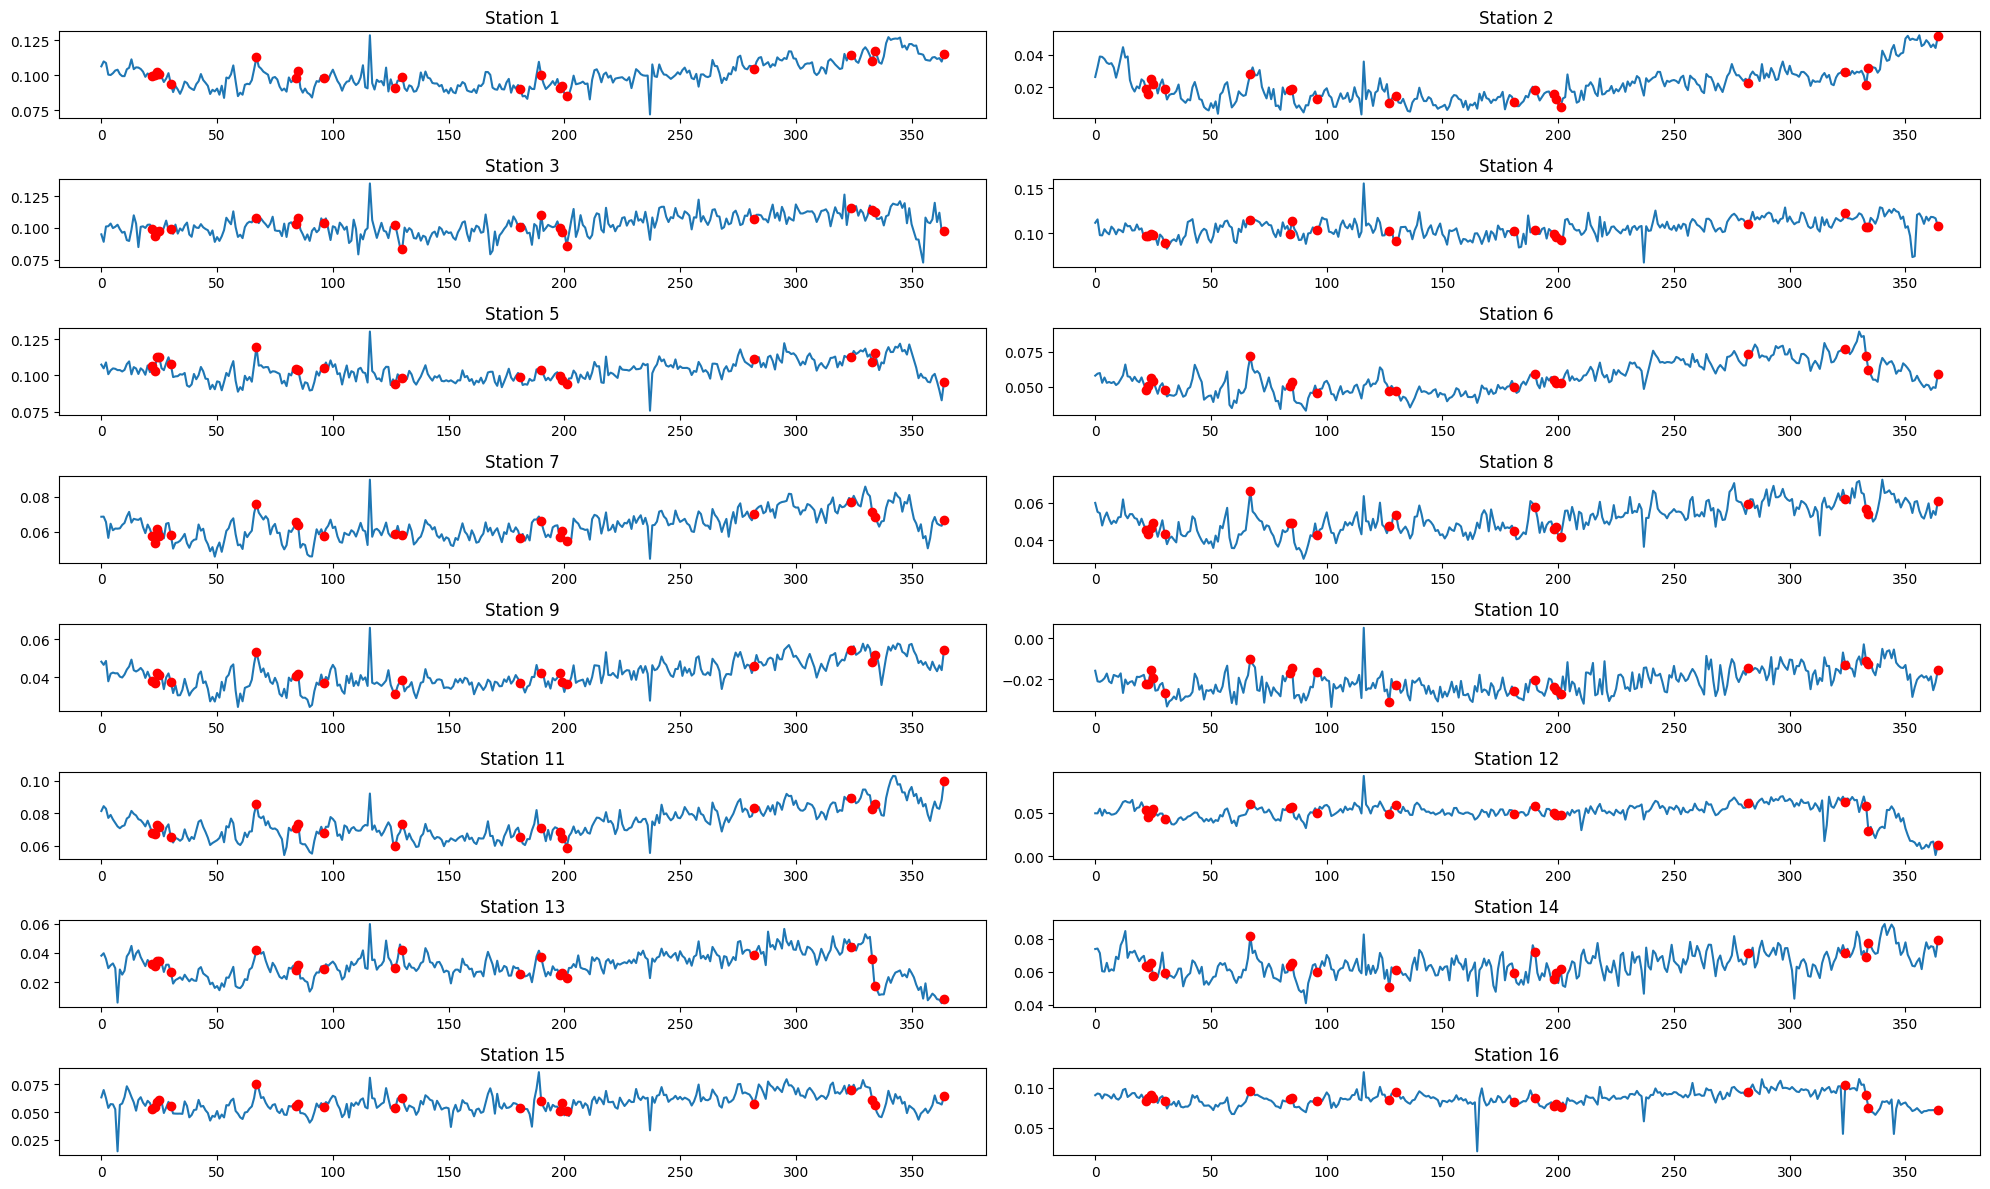

In [113]:
plt.figure(figsize=(20, 12))
es = 24
window_size = 13
for i in range(16):
    plt.subplot(8,2,i+1)
    plt.plot(GNSS_data[:, i])
    plt.title('Station ' + str(i+1))
    plt.plot(es_id.flatten(), GNSS_data[es_id, i], 'ro')
plt.tight_layout()
plt.show()

In [114]:
window_len = 4
altitude_matrix_data = GNSS_data.T[:, :]
newdata = np.zeros((altitude_matrix_data.shape[0],
                    altitude_matrix_data.shape[1] - window_len + 1))

for i in range(newdata.shape[1]):
    newdata[:, i] = np.mean(altitude_matrix_data[:, i:i + window_len], axis=1)
newdata = np.hstack((np.zeros((newdata.shape[0], window_len-1)), newdata)) 

In [115]:
newdata = newdata.T

In [116]:
newdata.shape

(365, 16)

In [117]:
newdata[:,0]

array([0.        , 0.        , 0.        , 0.10629795, 0.10474472,
       0.10263108, 0.10128316, 0.10216368, 0.10232658, 0.10181206,
       0.10080684, 0.10088339, 0.10202368, 0.10502205, 0.10626755,
       0.10661595, 0.10664407, 0.10491976, 0.10447268, 0.10277546,
       0.10172403, 0.10057265, 0.09977318, 0.10004366, 0.10024831,
       0.10042212, 0.10025433, 0.0990594 , 0.09793877, 0.09817036,
       0.09696347, 0.09516027, 0.09385432, 0.09094535, 0.08915759,
       0.08975821, 0.09053445, 0.09167811, 0.09286488, 0.09284857,
       0.09133131, 0.09111756, 0.09218625, 0.09482877, 0.09661467,
       0.09686848, 0.09604096, 0.09247339, 0.09072877, 0.08919022,
       0.08869706, 0.08856964, 0.08929394, 0.08813522, 0.09011507,
       0.09303478, 0.09507542, 0.10088563, 0.10022161, 0.09704457,
       0.09376251, 0.08851771, 0.08788509, 0.09009084, 0.0916067 ,
       0.09421398, 0.09699996, 0.10174283, 0.10490911, 0.10696502,
       0.10652799, 0.10368037, 0.10221072, 0.09960944, 0.09851

In [118]:
GNSS_data[:4,0].mean()

0.10629795312499997

In [119]:
es_id

array([ 22,  23,  24,  25,  30,  67,  84,  85,  96, 127, 130, 181, 190,
       198, 199, 201, 282, 324, 333, 334, 364])

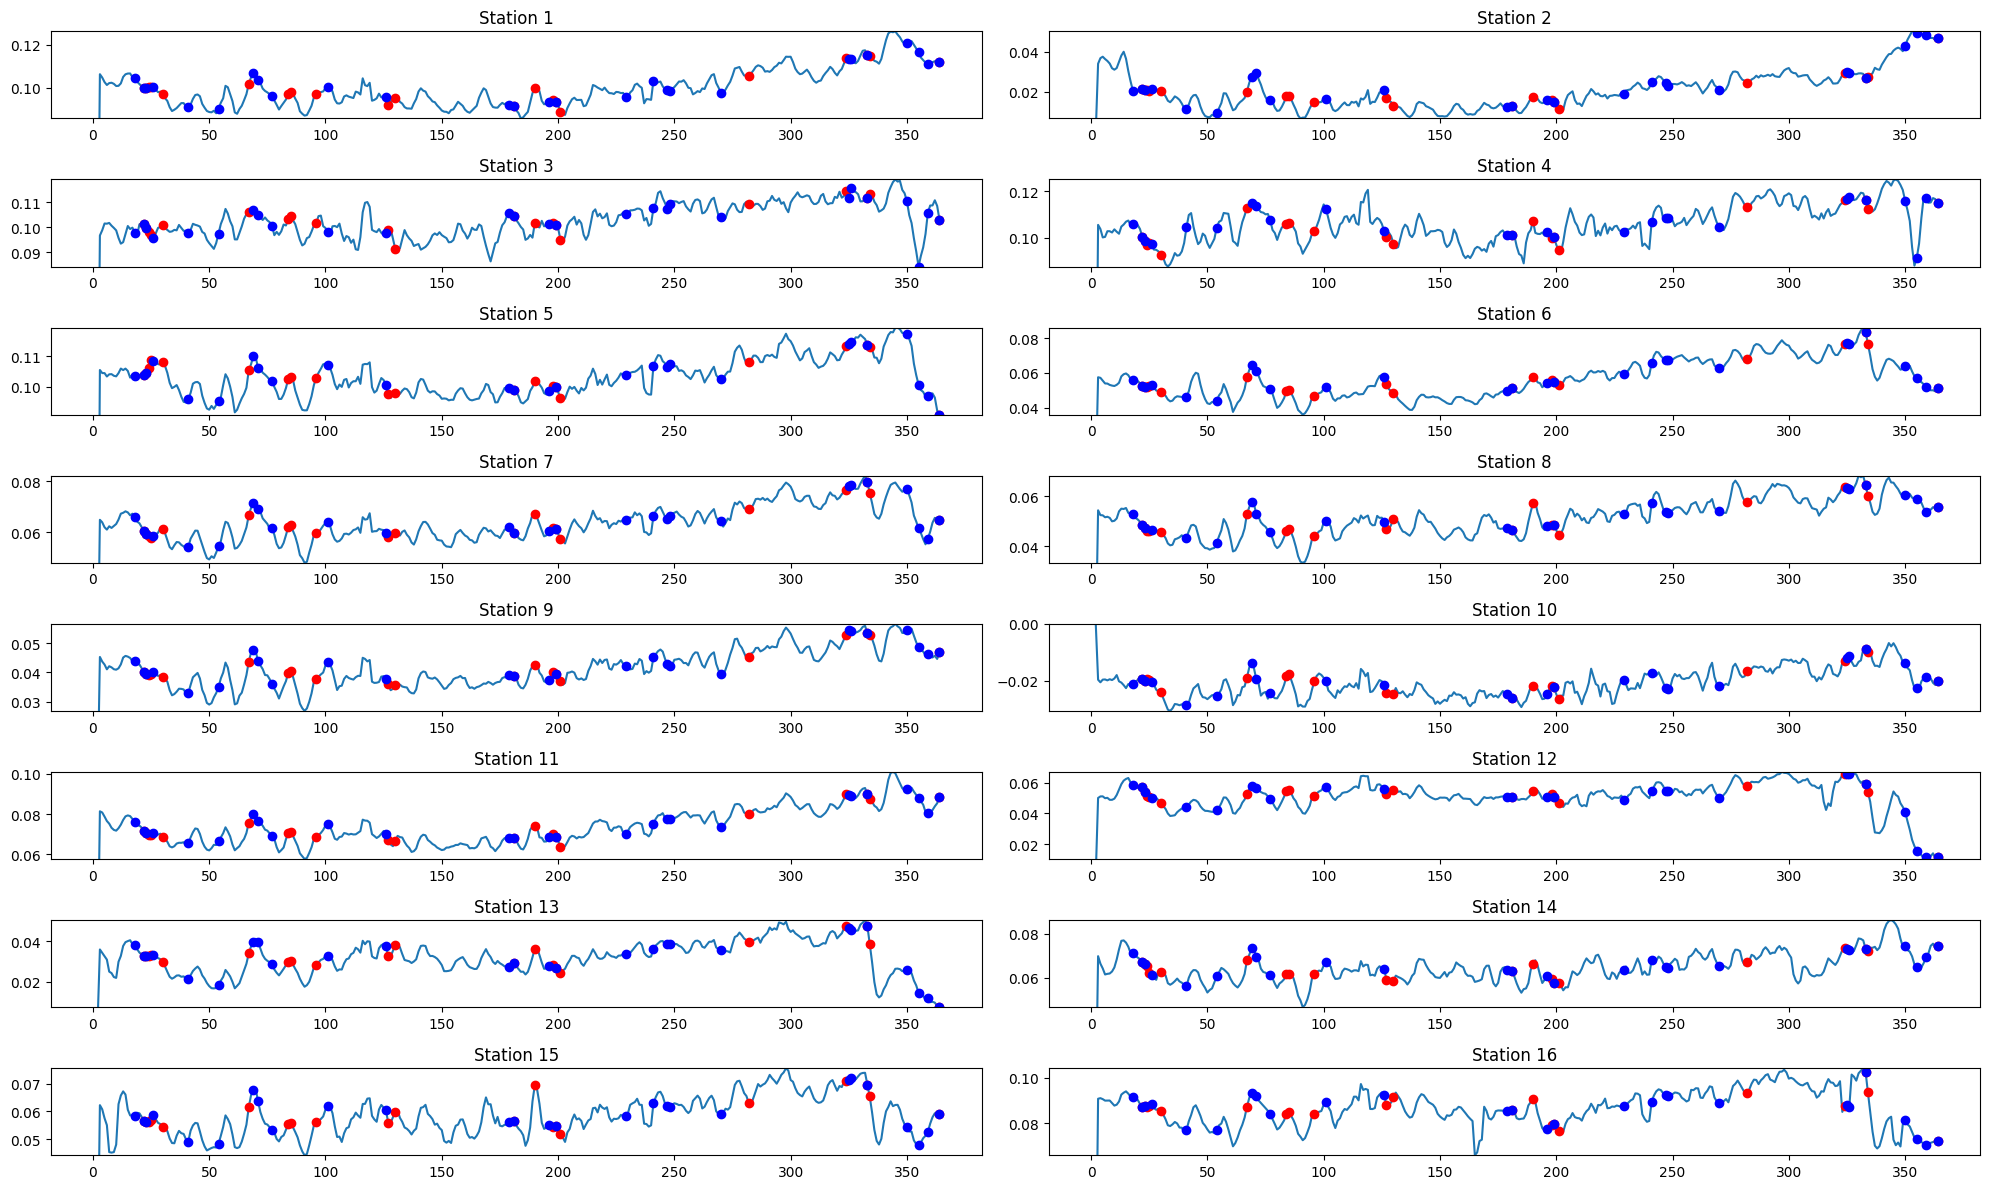

In [120]:
plt.figure(figsize=(20, 12))
es = 24
window_size = 13
for i in range(16):
    plt.subplot(8,2,i+1)
    plt.plot(newdata[:, i])
    plt.title('Station ' + str(i+1))
    
    plt.plot(es_id.flatten(), newdata[es_id, i], 'ro')
    plt.plot(mark,newdata[mark, i], 'bo')
    plt.ylim(np.min(newdata[5:, i]), np.max(newdata[:, i]))
    # plt.plot(GNSS_data[:, i])
plt.tight_layout()
plt.show()

In [121]:
newdata.shape

(365, 16)

In [122]:
window_len = 4
altitude_matrix_data = GNSS_data.T[:, :]  # 输入数据
newdata_h = np.zeros((altitude_matrix_data.shape[0],
                    altitude_matrix_data.shape[1] - window_len + 1))

# 过去平滑：窗口只依赖当前及之前的数据
for i in range(newdata_h.shape[1]):
    newdata_h[:, i] = np.mean(altitude_matrix_data[:, max(0, i - window_len + 1):i + 1], axis=1)

# 填补前面 0，使结果对齐
newdata_h = np.hstack((np.zeros((newdata_h.shape[0], window_len - 1)), newdata_h)).T

In [125]:
i= 1

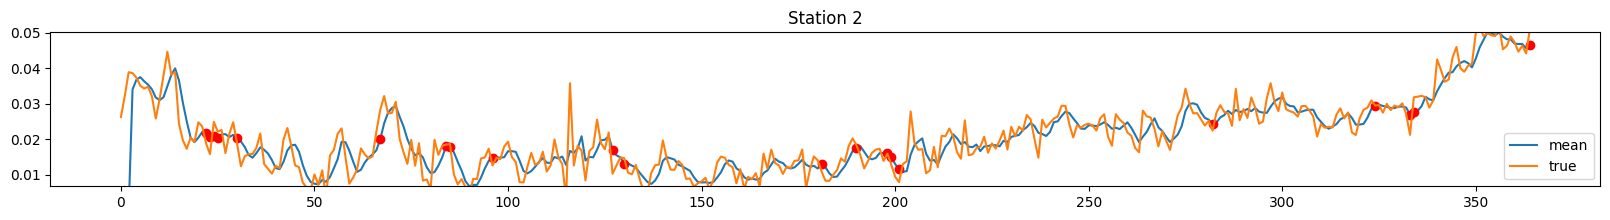

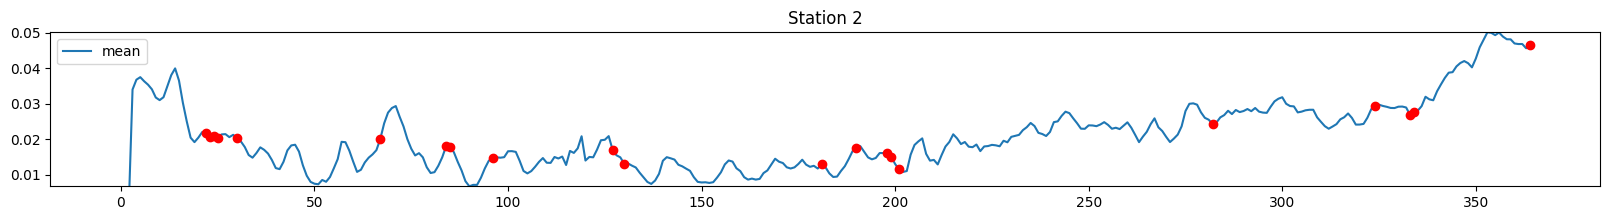

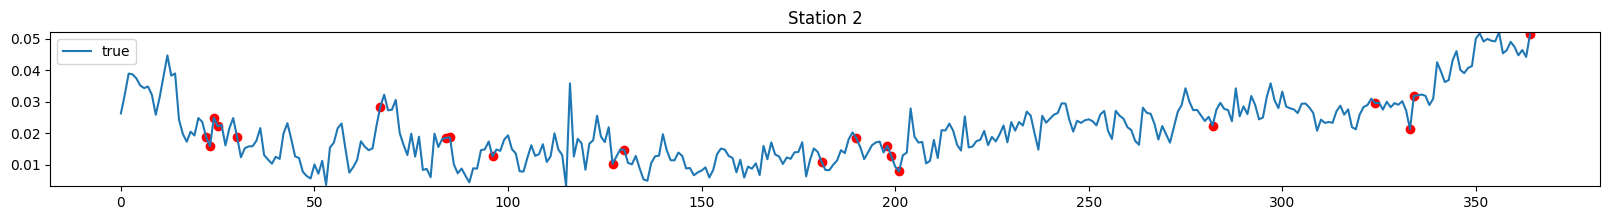

In [126]:
plt.figure(figsize=(20,2))
plt.plot(newdata[:, i],label = "mean")
plt.title('Station ' + str(i+1))
plt.plot(es_id.flatten(), newdata[es_id, i], 'ro')
plt.ylim(np.min(newdata[5:, i]), np.max(newdata[:, i]))
plt.plot(GNSS_data[:, i],label = "true")
plt.legend()
plt.show()
plt.figure(figsize=(20,2))
plt.plot(newdata[:, i],label = "mean")
plt.title('Station ' + str(i+1))
plt.plot(es_id.flatten(), newdata[es_id, i], 'ro')
plt.ylim(np.min(newdata[5:, i]), np.max(newdata[:, i]))
plt.legend()
plt.show()
plt.figure(figsize=(20,2))
plt.title('Station ' + str(i+1))
plt.plot(es_id.flatten(), GNSS_data[es_id, i], 'ro')
plt.ylim(np.min(GNSS_data[5:, i]), np.max(GNSS_data[:, i]))
plt.plot(GNSS_data[:, i],label = "true")
plt.legend()
plt.show()

In [64]:
Y2 = [0,1,0]
single = [0,1,0]

In [71]:
import numpy as np

# 示例数据
starday = 2
Y2 = np.zeros(365)
single = np.zeros(365)
ydata = Y2.copy()  # ydata 的长度与 Y2 相同
Y2[100] = 1
single[100] = 1
# 初始化变量
earthquake = 0
accur_earthqu = []  # 记录满足条件的地震索引
acuur_single = np.zeros_like(single)  # 标记 single 中预测成功的位置

# 核心代码
for i in range(starday, len(Y2)):
    if Y2[i] != 0:  # 检测 Y2 中非零值（表示地震事件）
        earthquake += 1  # 地震事件计数
        a = max(0, i - 14)  # 设置时间窗口左边界
        b = min(len(ydata) - 1, i)  # 设置时间窗口右边界

        if np.any(single[a:b+1] == 1):  # 检查窗口内是否有 single == 1
            accur_earthqu.append(i)  # 记录地震索引
            acuur_single[np.where(single[a:b+1] == 1)[0] + a] = 1  # 标记 single 中的位置